<a href="https://colab.research.google.com/github/vaisanthragavc2025-pixel/vaisanth-EDA/blob/main/25BAI0145_EXP9_15.09.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Exploring Relationships with Other Visualizations**

**Correlation Heatmap**

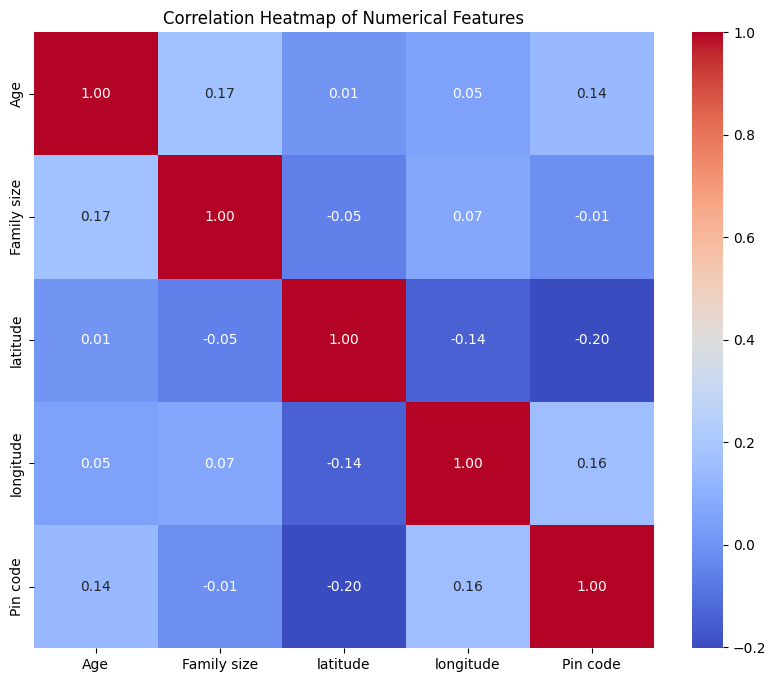

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(food_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Pair Plots**

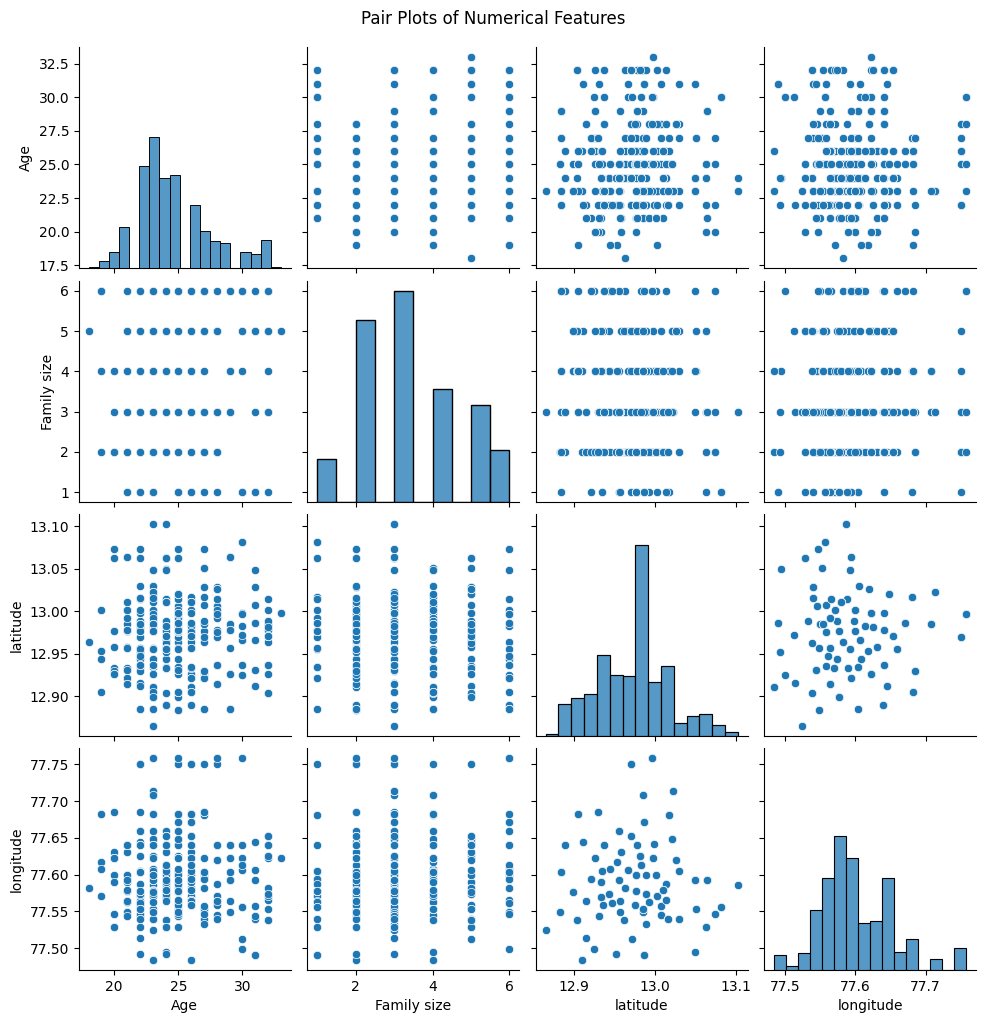

In [17]:
sns.pairplot(food_df, vars=['Age', 'Family size', 'latitude', 'longitude'])
plt.suptitle('Pair Plots of Numerical Features', y=1.02)
plt.show()

**Pie Chart for Gender Distribution**

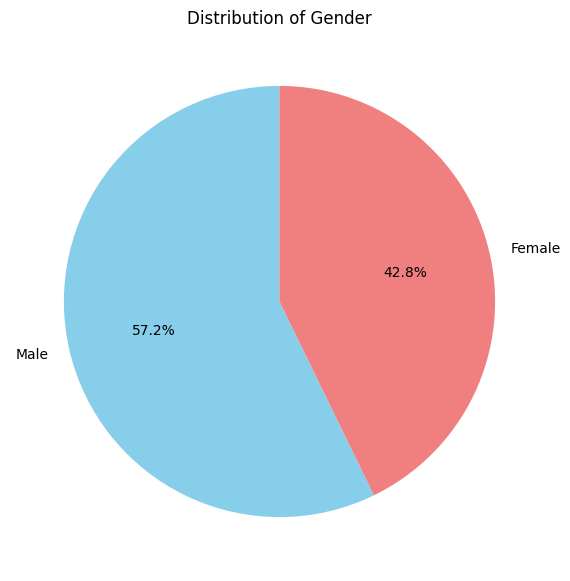

In [18]:
gender_counts = food_df['Gender'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Gender')
plt.ylabel('') # Hide the default 'y' label
plt.show()

### Word Cloud for Feedback

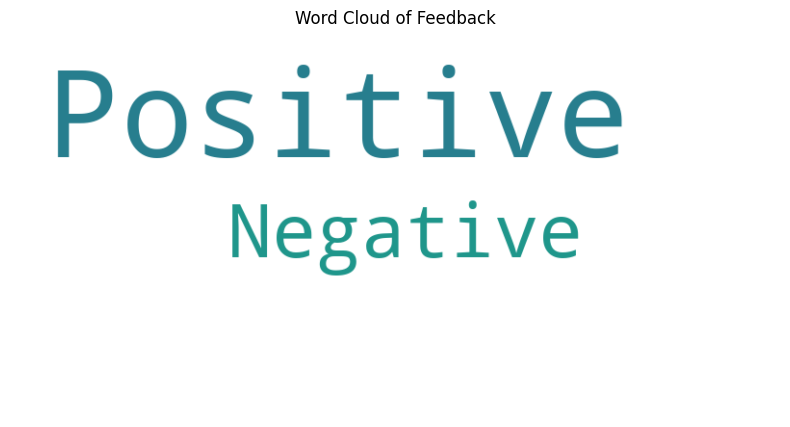

In [37]:
from wordcloud import WordCloud

# Combine all feedback into a single string
all_feedback = ' '.join(food_df['Feedback'].astype(str))

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_feedback)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Feedback')
plt.show()

### Dendrograms for Hierarchical Clustering

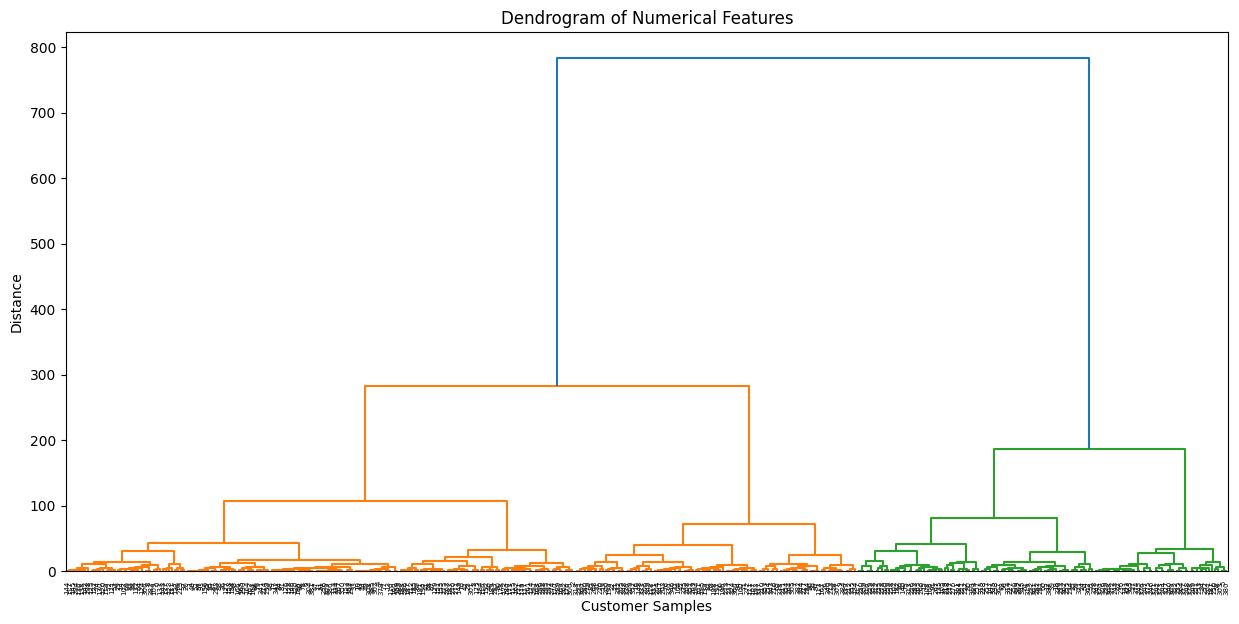

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Select numerical columns for clustering
num_cols_for_dendrogram = food_df[['Age', 'Family size', 'latitude', 'longitude', 'Pin code']]

# Perform hierarchical clustering
linked = linkage(num_cols_for_dendrogram, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram of Numerical Features')
plt.xlabel('Customer Samples')
plt.ylabel('Distance')
plt.show()

### Parallel Coordinate Plots

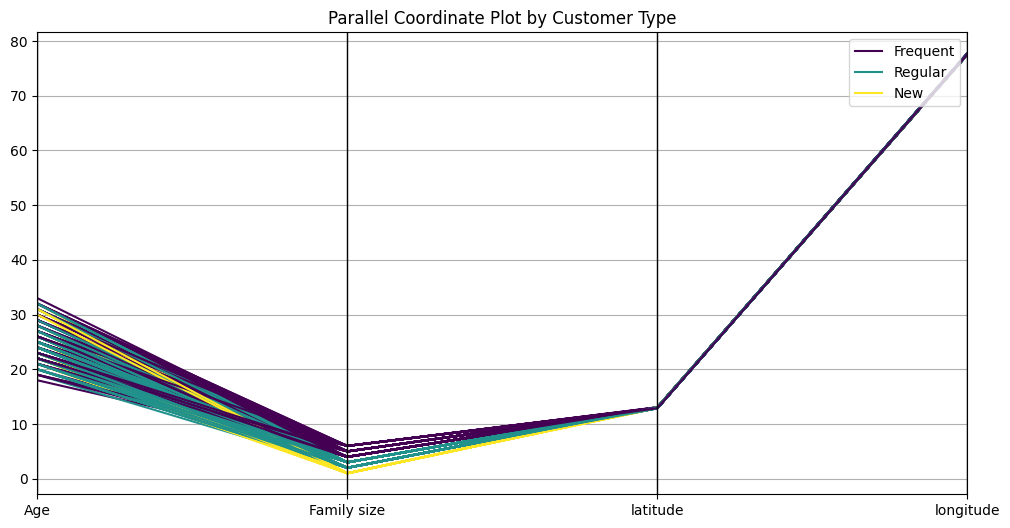

In [24]:
from pandas.plotting import parallel_coordinates

# Select some numerical columns and a categorical column for parallel coordinates
# It's better to convert categorical column to numerical for better visualization

# Let's use a subset of numerical columns and 'Customer Type' as the class column
# If 'Monthly Income' is categorical but ordered, we could try to map it to numerical.
# For now, let's just use numerical data and one categorical to color by.

# Create a copy to avoid SettingWithCopyWarning
df_parallel = food_df[['Age', 'Family size', 'latitude', 'longitude', 'Customer Type']].copy()

plt.figure(figsize=(12, 6))
parallel_coordinates(df_parallel, 'Customer Type', colormap='viridis')
plt.title('Parallel Coordinate Plot by Customer Type')
plt.show()

### Andrews Curves

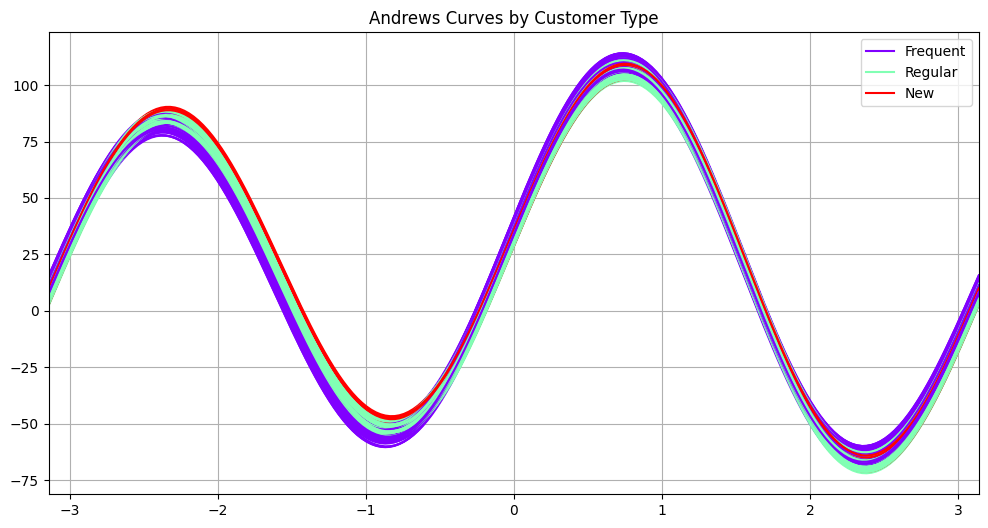

In [25]:
from pandas.plotting import andrews_curves

# Select numerical columns for Andrews Curves
# Andrews Curves work best with numerical data and a categorical column for coloring

# Create a copy to avoid SettingWithCopyWarning
df_andrews = food_df[['Age', 'Family size', 'latitude', 'longitude', 'Customer Type']].copy()

plt.figure(figsize=(12, 6))
andrews_curves(df_andrews, 'Customer Type', colormap='rainbow')
plt.title('Andrews Curves by Customer Type')
plt.show()

### Word Cloud for Feedback

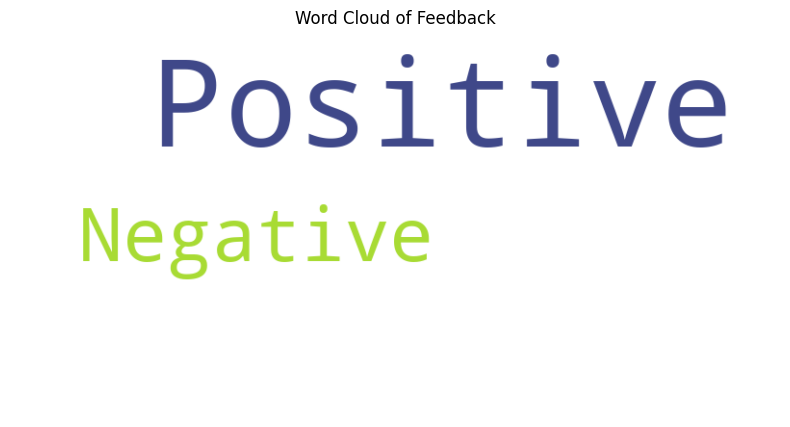

In [19]:
from wordcloud import WordCloud

# Combine all feedback into a single string
all_feedback = ' '.join(food_df['Feedback'].astype(str))

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_feedback)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Feedback')
plt.show()

### Geographical Distribution (Scatter Map)

In [20]:
import plotly.express as px

# Create a scatter map to visualize customer locations
fig = px.scatter_mapbox(food_df,
                        lat="latitude",
                        lon="longitude",
                        zoom=10, # Adjust zoom level as needed
                        hover_name="Pin code",
                        hover_data=["Age", "Gender", "Marital Status", "Occupation"],
                        title="Geographical Distribution of Customers")

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

### Loading the new dataset: `/content/online food delivery dataset.csv`

In [5]:
food_df = pd.read_csv('/content/online food delivery dataset.csv')
display(food_df.head())

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


In [6]:
display(food_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
 13  Unnamed: 13                 388 non

None

In [7]:
display(food_df.describe())

,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


### Visualizing Categorical Features

/tmp/ipykernel_915/4179451127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=food_df, x=col, palette='viridis')
/tmp/ipykernel_915/4179451127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=food_df, x=col, palette='viridis')
/tmp/ipykernel_915/4179451127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=food_df, x=col, palette='viridis')
/tmp/ipykernel_915/4179451127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` a

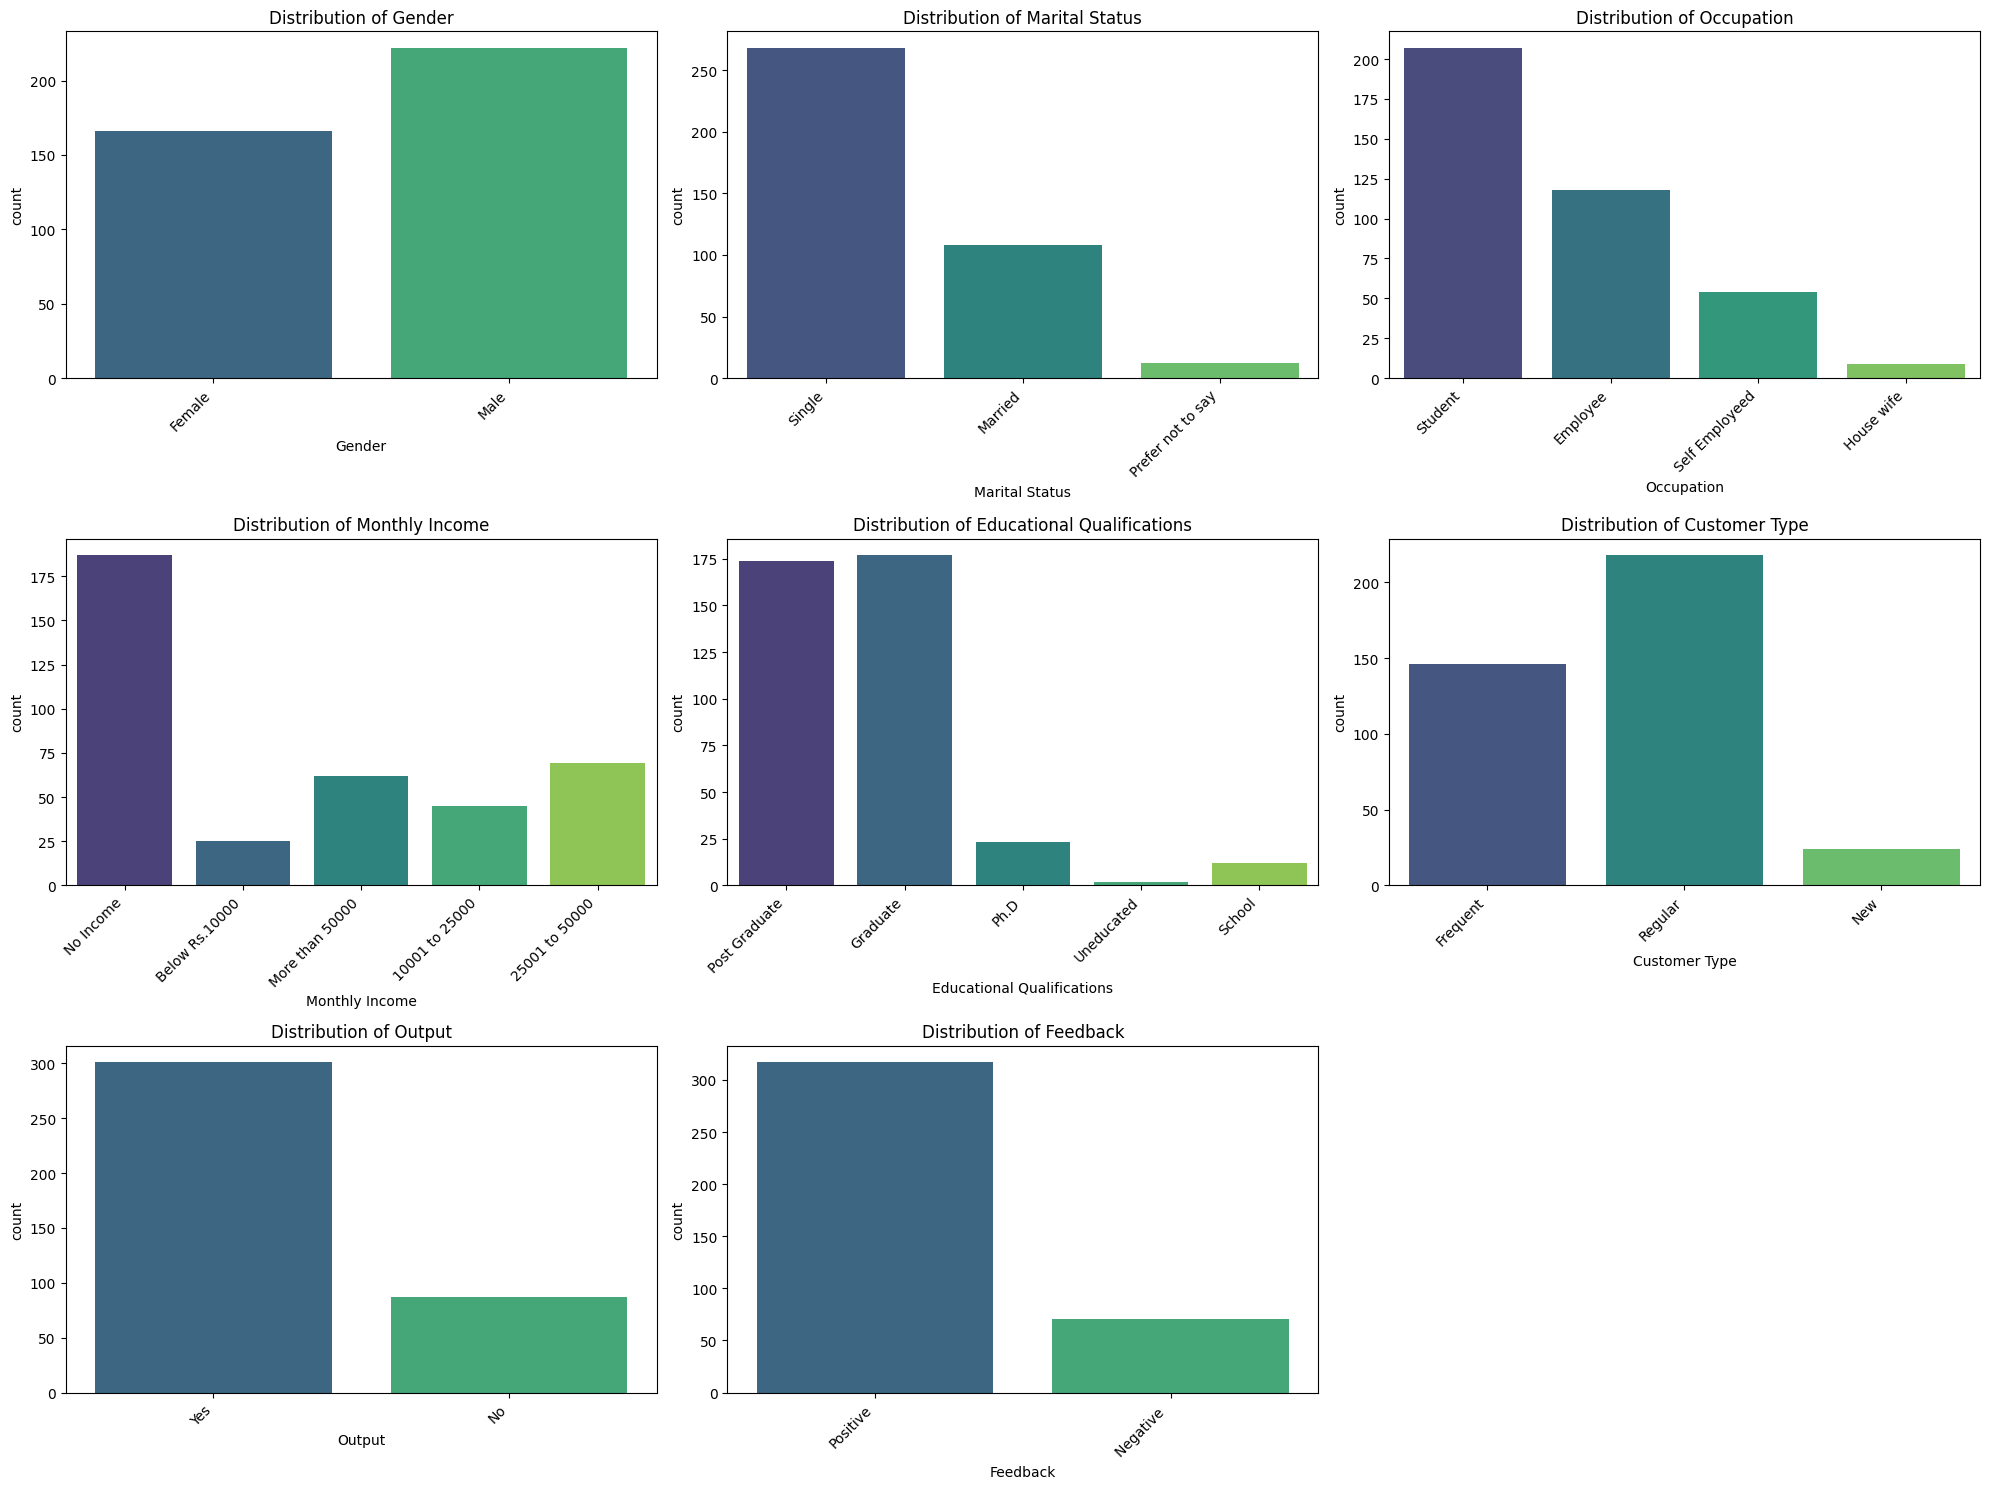

In [14]:
# List of categorical columns to plot
categorical_cols = ['Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Customer Type', 'Output', 'Feedback']

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(data=food_df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualizing Numerical Features

/tmp/ipykernel_915/1595186447.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=food_df, x=col, kde=True, bins=10, palette='magma')
/tmp/ipykernel_915/1595186447.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=food_df, x=col, kde=True, bins=10, palette='magma')


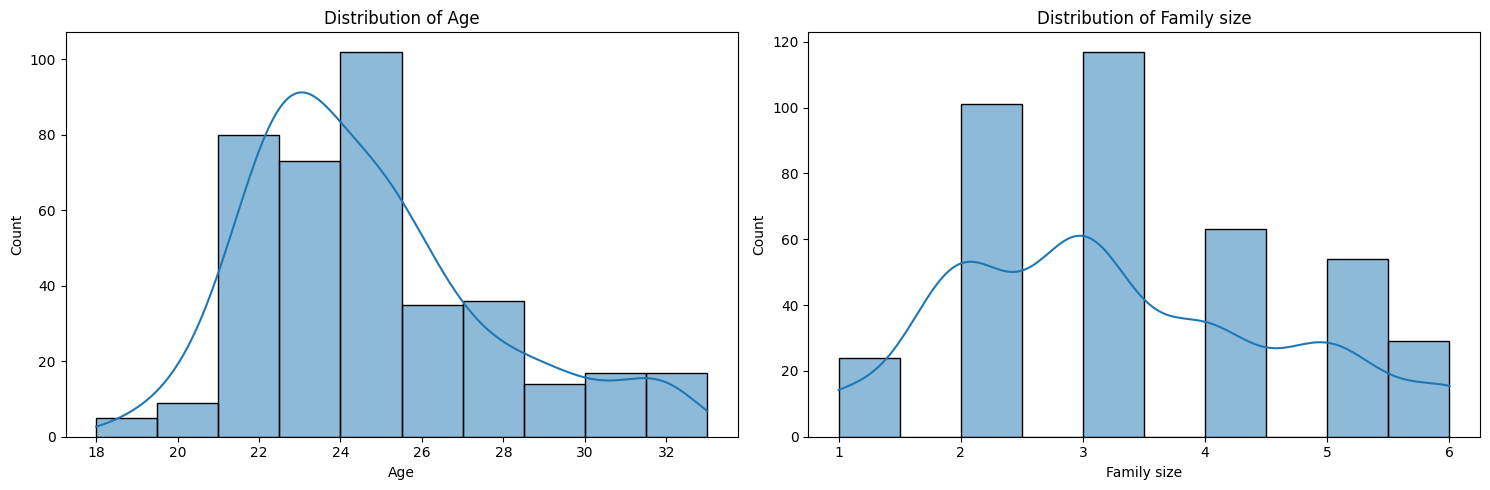

In [15]:
# List of numerical columns to plot histograms
numerical_cols = ['Age', 'Family size'] # latitude, longitude, and Pin code might not be as insightful as histograms

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 2, i + 1)
    sns.histplot(data=food_df, x=col, kde=True, bins=10, palette='magma')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Initial Data Exploration and Cleaning

In [8]:
# Check the unique values and their counts for 'Unnamed: 13'
display(food_df['Unnamed: 13'].value_counts())

,count
Unnamed: 13,
Yes,301
No,87


It seems that the column `Unnamed: 13` contains only 'Yes' values, making it uninformative for analysis. I will drop this column.

In [9]:
food_df = food_df.drop(columns=['Unnamed: 13'])
display(food_df.head())

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive
